# 10. Переобучение и ранняя остановка на 300 шумных объектах

| | |
|---|---|
| **Уровень** | 2 из 4 — маленькие данные: реальные наборы и базовые приёмы (`2_small`) |
| **Скрипт-источник** | [`10_overfitting_early_stopping.py`](../10_overfitting_early_stopping.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 3 с |

**Цель.** Увидеть переобучение бустинга своими глазами и научиться его останавливать.

### Чему вы научитесь

- Кривые ошибки на обучении и валидации
- Лучшая итерация
- Ранняя остановка в LightGBM (`lgb.early_stopping`)
- Почему решение принимается на валидации, а оценка — на отдельном тесте

### Данные

Задача Фридмана — 300 объектов для обучения, 10 признаков (5 информативных, 5 шумовых), сильный шум σ = 2; 300 для валидации и 5000 для теста.

### План

1. **Этап 1.** Данные
2. **Этап 2.** 2000 деревьев, ν = 0.1, 7 листьев — без остановки
3. **Этап 4.** Ранняя остановка: прекратить, если 50 деревьев подряд нет улучшения на валидации
4. **Этап 5.** Картинка

> Ноутбук собран из `examples/2_small/10_overfitting_early_stopping.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "2_small/10_overfitting_early_stopping.py", title="10. Переобучение и ранняя остановка",
             goal="найти момент, когда новые деревья начинают вредить, и остановиться")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from gbcourse import datasets

## Этап 1. Данные

In [2]:
X, y = datasets.friedman1(n=5600, noise=2.0, seed=10)
X_tr, y_tr, X_va, y_va, X_te, y_te = X[:300], y[:300], X[300:600], y[300:600], X[600:], y[600:]
ex.describe(X_tr, y_tr, names=[f"x{j}" for j in range(10)], target="y",
            source="gbcourse.datasets.friedman1: y = 10 sin(πx0x1) + 20(x2 − 0.5)² + 10x3 + 5x4 + шум")
ex.note("Шум σ = 2, значит лучшая возможная RMSE ≈ 2.")

   Источник: gbcourse.datasets.friedman1: y = 10 sin(πx0x1) + 20(x2 − 0.5)² + 10x3 + 5x4 + шум
   Объектов: 300   признаков: 10   память: 0.02 МБ
   Типы признаков: float64 × 10
   Пропусков нет
   Цель «y»: среднее 14.520, σ 5.149, мин 2.301, макс 28.311
   Первые строки:


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,[y]
0,0.501992,0.917487,0.691318,0.802103,0.457418,0.448346,0.202287,0.083561,0.034127,0.996719,24.070661
1,0.392773,0.388061,0.444315,0.925671,0.291137,0.808164,0.936041,0.157890,0.388704,0.695380,12.972598
2,0.294584,0.342332,0.383990,0.517226,0.045862,0.512709,0.038490,0.074316,0.204047,0.146532,9.311643


> ▸ **Вывод.** Шум σ = 2, значит лучшая возможная RMSE ≈ 2.

## Этап 2. 2000 деревьев, ν = 0.1, 7 листьев — без остановки

In [3]:
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
m = lgb.LGBMRegressor
full = m(n_estimators=2000, learning_rate=0.1, num_leaves=7, min_child_samples=20, verbose=-1, random_state=0)
full.fit(X_tr, y_tr, eval_X=(X_tr, X_va), eval_y=(y_tr, y_va), eval_names=["обучение", "валидация"], eval_metric="rmse")
tr_curve = np.array(full.evals_result_["обучение"]["rmse"])
va_curve = np.array(full.evals_result_["валидация"]["rmse"])
best = int(np.argmin(va_curve)) + 1
print(f"   RMSE обучение после 2000 деревьев: {tr_curve[-1]:.3f} — почти ноль, модель запомнила 300 объектов вместе с шумом")
print(f"   RMSE валидация: лучшая {va_curve.min():.3f} на {best}-м дереве, после 2000 — {va_curve[-1]:.3f}")
assert va_curve[-1] > va_curve.min()
ex.note("""Рост ошибки после лучшей итерации умеренный: когда обучение подогнано почти идеально, градиенты почти нулевые,
и новые деревья мало что меняют. Лишние деревья вредят немного, а время тратят полностью.""")

   RMSE обучение после 2000 деревьев: 0.002 — почти ноль, модель запомнила 300 объектов вместе с шумом
   RMSE валидация: лучшая 2.687 на 77-м дереве, после 2000 — 2.792


> ▸ **Вывод.** Рост ошибки после лучшей итерации умеренный: когда обучение подогнано почти идеально, градиенты почти нулевые, и новые деревья мало что меняют. Лишние деревья вредят немного, а время тратят полностью.

## Этап 4. Ранняя остановка: прекратить, если 50 деревьев подряд нет улучшения на валидации

In [4]:
es = m(n_estimators=2000, learning_rate=0.1, num_leaves=7, min_child_samples=20, verbose=-1, random_state=0)
with ex.timer("обучение с ранней остановкой"):
    es.fit(X_tr, y_tr, eval_X=(X_va,), eval_y=(y_va,), eval_metric="rmse", callbacks=[lgb.early_stopping(50, verbose=False)])
print(f"   остановились на {es.best_iteration_} деревьях")
print(f"   RMSE на тесте: без остановки {rmse(y_te, full.predict(X_te)):.3f}, с остановкой {rmse(y_te, es.predict(X_te)):.3f}")
ex.note("""Валидацию использовали для выбора числа деревьев, поэтому оценку качества даёт только тест.
Ранняя остановка дешевле и надёжнее, чем подбирать число деревьев вручную.""")
assert rmse(y_te, es.predict(X_te)) < rmse(y_te, full.predict(X_te))

   ⏱ обучение с ранней остановкой: 0.02 с
   остановились на 77 деревьях
   RMSE на тесте: без остановки 2.815, с остановкой 2.759


> ▸ **Вывод.** Валидацию использовали для выбора числа деревьев, поэтому оценку качества даёт только тест. Ранняя остановка дешевле и надёжнее, чем подбирать число деревьев вручную.

## Этап 5. Картинка

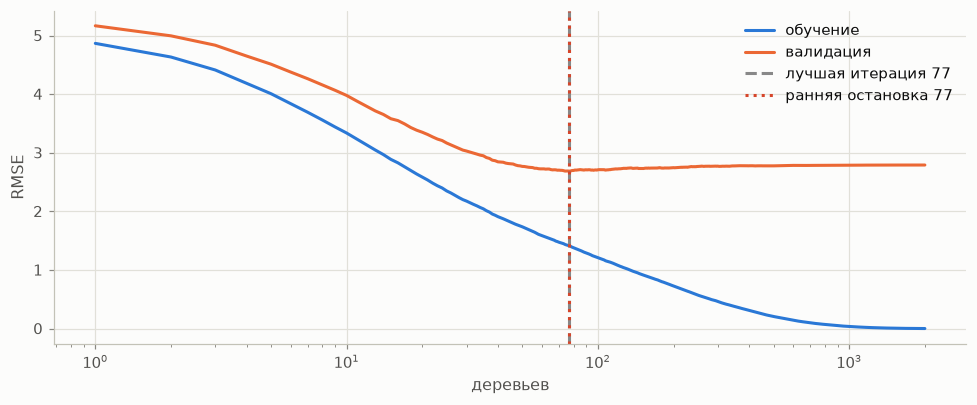

Готово за 1.4 с


In [5]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(np.arange(1, 2001), tr_curve, label="обучение")
ax.plot(np.arange(1, 2001), va_curve, label="валидация")
ax.axvline(best, color="#888", ls="--", label=f"лучшая итерация {best}")
ax.axvline(es.best_iteration_, color="#d6452a", ls=":", label=f"ранняя остановка {es.best_iteration_}")
ax.set(xscale="log", xlabel="деревьев", ylabel="RMSE")
ax.legend()
fig.tight_layout()
ex.finish(fig, "10_early_stopping")
ex.done()

## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Уменьшите `learning_rate` до 0.02 — где теперь минимум валидационной кривой и насколько он глубже?
2. Увеличьте обучающую выборку с 300 до 3000 объектов — насколько слабее станет переобучение?
3. Поставьте `min_child_samples=5` и сравните форму кривых после минимума.

## Что дальше

- **Теория в курсе:** [7 «Регуляризация»](../../../lessons/lesson_7/README.md), [7.1 «Ранняя остановка»](../../../lessons/lesson_7_1/README.md).
- **Предыдущий пример:** [09. Многоклассовая классификация: реальные данные «Вино» (178 образцов, 3 сорта)](09_multiclass_wine.ipynb)
- **Следующий пример:** [11. XGBoost от начала до конца: цены квартир, 20 000 объектов](../../3_medium/notebooks/11_xgboost_complete.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)